# HW4 Part 2 (Bonus) — Interactive AWGN Communication System
**CS515 Deep Learning | Sabanci University**

This notebook:
1. Clones the repo and verifies the environment
2. Runs pre-training smoke tests to validate all components
3. Trains the end-to-end TX + RX communication system
4. Evaluates over all 4096 messages × 100 noise trials
5. Displays metrics and plots, then downloads results

> **Important:** Runtime → Change runtime type → **T4 GPU** must be selected.

## 0. GPU Check

In [2]:
import torch

print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected — select T4 GPU from the Runtime menu.')

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


## 1. Repo Setup

In [3]:
import os

REPO_URL = 'https://github.com/caltinuzengi/cs515-deep-learning.git'
REPO_DIR = 'cs515-deep-learning'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    print('Repo already exists, pulling latest changes...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')

Cloning into 'cs515-deep-learning'...
remote: Enumerating objects: 461, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (58/58), done.
remote: Total 461 (delta 36), reused 61 (delta 24), pack-reused 378 (from 3)
Receiving objects: 100% (461/461), 508.55 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (280/280), done.
Working directory: /content/cs515-deep-learning


## 2. Environment Check

The bonus experiment requires only PyTorch and matplotlib, both pre-installed in Colab.

In [4]:
import torch
import matplotlib

print(f'torch      : {torch.__version__}')
print(f'matplotlib : {matplotlib.__version__}')
print(f'CUDA       : {torch.cuda.is_available()}')

torch      : 2.11.0+cu128
matplotlib : 3.10.0
CUDA       : True


## 3. Pre-training Smoke Tests

Validates all five components before any training starts:
- **Forward pass shapes** — logits `(B, 4, 8)`, x_t `(B, 4)`
- **Power constraint** — `||x_t||₂ ≤ 1.0` per sample
- **Initial loss** — near random baseline `ln(8) ≈ 2.079`
- **Initial accuracy** — near random baseline `1/8 = 0.125`
- **Gradient flow** — gradients reach both TXEncoder and RXDecoder

In [5]:
import sys
sys.path.insert(0, '.')

import torch
from models.TXEncoder import TXEncoder
from models.RXDecoder import RXDecoder
from bonus.comm_system import CommSystem
from bonus.experiment_bonus import run_smoke_tests
from bonus.config_bonus import (
    DEVICE, D_EMB, D_MODEL, N_HEADS, N_LAYERS, FFN_DIM, DROPOUT,
    T_ROUNDS, N_SYMBOLS, ALPHABET, SIGMA_SQ, EPS,
)

enc  = TXEncoder(D_EMB, D_MODEL, N_HEADS, N_LAYERS, FFN_DIM, DROPOUT,
                 T_ROUNDS, N_SYMBOLS, ALPHABET, EPS).to(DEVICE)
dec  = RXDecoder(T_ROUNDS, D_MODEL, N_HEADS, N_LAYERS, FFN_DIM, DROPOUT,
                 N_SYMBOLS, ALPHABET).to(DEVICE)
comm = CommSystem(enc, dec, SIGMA_SQ, T_ROUNDS)

run_smoke_tests(comm, enc, dec, DEVICE)

Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.1970  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1279  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.


## 4. Training

Trains the end-to-end communication system:
- **TX (TXEncoder):** Transformer-based encoder, runs at every round
- **RX (RXDecoder):** Transformer-based decoder, runs once after all rounds
- **Channel:** AWGN with σ² = 0.25, noiseless feedback relay
- **Optimizer:** AdamW, early stopping with patience = 20

Best checkpoint is saved to `results/bonus/checkpoints/best_model.pt`.

In [6]:
!python bonus/experiment_bonus.py

Config: T=4 | sigma_sq=0.25 | feedback=True | out_dir=results/bonus
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.1970  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1279  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1033 | val=2.0701 | sym_acc=0.1436 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.0746 | val=2.0899 | sym_acc=0.1367 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.1030 | val=2.0629 | sym_acc=0.1426 | msg_acc=0.0000 | power=1.000000
Epoch    4 | train=2.0627 | val=2.0208 | sym_acc=0.2197 | msg_acc=0.0000 | power=1.000000
Epoch    5 | train=2.0396 | val=2.0027 | sym_acc=0.2109 | msg_acc=0.0000 | power=1.000000
Epoch    6 | train=2.0203 | val=1.9997 | sym_acc=0.2295 | msg_acc=0.0039 | power=1.000000
Epoch    7 | train=2.0133 | val=1.9649 | sym_acc=0.2812 | msg_acc=0.0039 | po

## 5. Results — Evaluation Metrics

Full evaluation over all **4096 messages × 100 noise trials**.

In [7]:
import json

with open('results/bonus/metrics/eval_results.json') as f:
    metrics = json.load(f)

print('=' * 45)
print('  Full Evaluation Results')
print('=' * 45)
labels = {
    'ce_loss':          'CE Loss',
    'symbol_accuracy':  'Symbol Accuracy',
    'message_accuracy': 'Message Accuracy',
    'SER':              'Symbol Error Rate (SER)',
    'MER':              'Message Error Rate (MER)',
    'avg_power':        'Avg Power (≤ 1.0)',
}
for key, label in labels.items():
    print(f'  {label:<26}: {metrics[key]:.6f}')
print('=' * 45)

  Full Evaluation Results
  CE Loss                   : 0.895381
  Symbol Accuracy           : 0.645664
  Message Accuracy          : 0.203582
  Symbol Error Rate (SER)   : 0.354336
  Message Error Rate (MER)  : 0.796418
  Avg Power (≤ 1.0)         : 1.000000


## 6. Results — Training Curves

--- Loss Curve ---


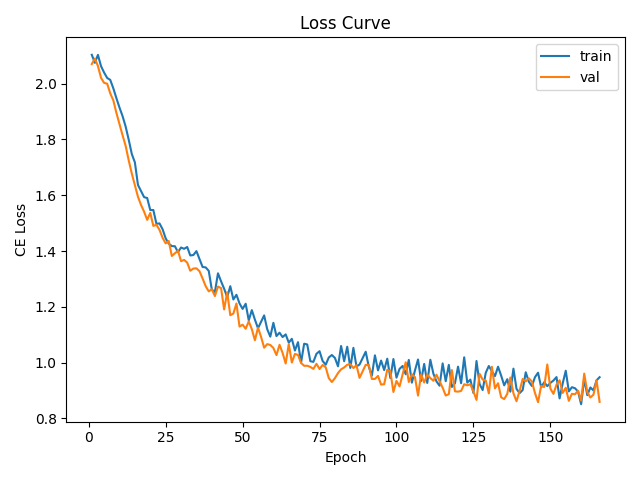

--- Accuracy Curve ---


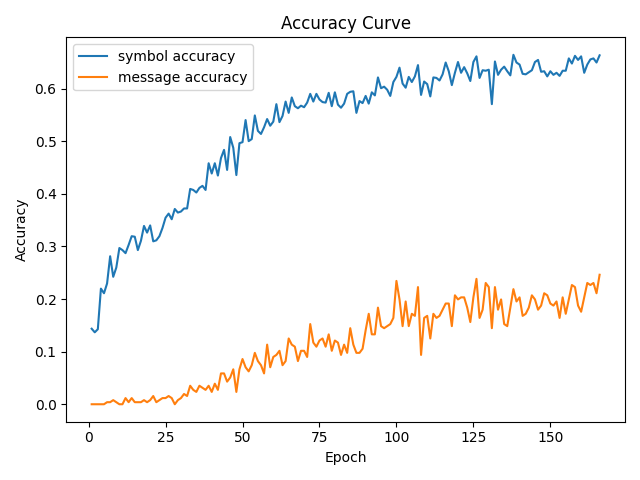

--- Power Curve ---


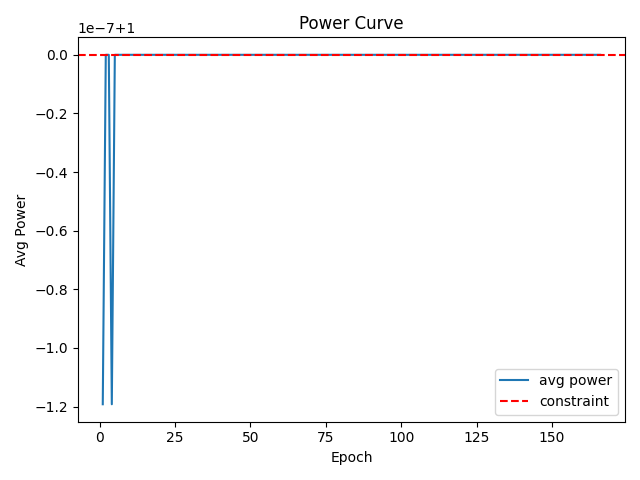

In [8]:
import os
from IPython.display import Image, display

plot_files = {
    'results/bonus/plots/loss_curve.png':     'Loss Curve',
    'results/bonus/plots/accuracy_curve.png': 'Accuracy Curve',
    'results/bonus/plots/power_curve.png':    'Power Curve',
}

missing = [p for p in plot_files if not os.path.exists(p)]
if missing:
    print('Missing plots — run the training cell first:', missing)
else:
    for path, title in plot_files.items():
        print(f'--- {title} ---')
        display(Image(filename=path))


## 7. Download Results

Downloads metrics and plots as a zip archive. Checkpoints are excluded due to size.

In [9]:
import base64, shutil, os
from IPython.display import display, HTML

tmp_dir = "/tmp/bonus_results"
os.makedirs(tmp_dir, exist_ok=True)
for sub in ("metrics", "plots"):
    shutil.copytree(f"results/bonus/{sub}", f"{tmp_dir}/{sub}", dirs_exist_ok=True)

zip_path = "/tmp/bonus_results"
shutil.make_archive(zip_path, "zip", tmp_dir)

with open(zip_path + ".zip", "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

size_kb = len(b64) * 3 // 4 // 1024
display(HTML(f"""
<a href="data:application/zip;base64,{b64}"
   download="bonus_results.zip"
   style="padding:8px 16px;background:#1a73e8;color:white;
          text-decoration:none;border-radius:4px;font-family:sans-serif;">
    &#11015; Download bonus_results.zip ({size_kb} KB)
</a>
"""))


---
## 8. Ablation 1 — Round Ablation (T = 1, 2, 3, 4)

Trains a separate model for each number of communication rounds T in {1, 2, 3, 4}.
- **T = 4** is the baseline already trained above.
- Each model is saved to `results/bonus/ablations/rounds_T{n}/`.

**Research question:** How much does each additional round (and feedback) improve SER?


In [10]:
!python bonus/experiment_bonus.py --t-rounds 1 --out-dir results/bonus/ablations/rounds_T1


Config: T=1 | sigma_sq=0.25 | feedback=True | out_dir=results/bonus/ablations/rounds_T1
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.3094  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1152  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1482 | val=2.0767 | sym_acc=0.1309 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.0815 | val=2.0790 | sym_acc=0.1191 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.0844 | val=2.0647 | sym_acc=0.1436 | msg_acc=0.0039 | power=1.000000
Epoch    4 | train=2.0698 | val=2.0446 | sym_acc=0.1562 | msg_acc=0.0000 | power=1.000000
Epoch    5 | train=2.0577 | val=2.0049 | sym_acc=0.1914 | msg_acc=0.0039 | power=1.000000
Epoch    6 | train=2.0032 | val=1.9762 | sym_acc=0.2295 | msg_acc=0.0039 | power=1.000000
Epoch    7 | train=1.9845 | val=1.9424 | sym_acc=0.2461 |

In [11]:
!python bonus/experiment_bonus.py --t-rounds 2 --out-dir results/bonus/ablations/rounds_T2


Config: T=2 | sigma_sq=0.25 | feedback=True | out_dir=results/bonus/ablations/rounds_T2
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.1776  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1221  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1065 | val=2.1365 | sym_acc=0.1406 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.1544 | val=2.0997 | sym_acc=0.1504 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.1017 | val=2.0736 | sym_acc=0.1162 | msg_acc=0.0000 | power=1.000000
Epoch    4 | train=2.0859 | val=2.1032 | sym_acc=0.1133 | msg_acc=0.0000 | power=1.000000
Epoch    5 | train=2.0947 | val=2.0529 | sym_acc=0.2041 | msg_acc=0.0000 | power=1.000000
Epoch    6 | train=2.0691 | val=2.0496 | sym_acc=0.1221 | msg_acc=0.0000 | power=1.000000
Epoch    7 | train=2.0559 | val=2.0081 | sym_acc=0.1562 |

In [12]:
!python bonus/experiment_bonus.py --t-rounds 3 --out-dir results/bonus/ablations/rounds_T3


Config: T=3 | sigma_sq=0.25 | feedback=True | out_dir=results/bonus/ablations/rounds_T3
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.3004  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1328  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1324 | val=2.0715 | sym_acc=0.1816 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.0695 | val=2.0916 | sym_acc=0.1455 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.0958 | val=2.0256 | sym_acc=0.1523 | msg_acc=0.0000 | power=1.000000
Epoch    4 | train=2.0427 | val=2.0567 | sym_acc=0.1611 | msg_acc=0.0000 | power=1.000000
Epoch    5 | train=2.0765 | val=2.0045 | sym_acc=0.1719 | msg_acc=0.0000 | power=1.000000
Epoch    6 | train=2.0220 | val=1.9724 | sym_acc=0.2012 | msg_acc=0.0000 | power=1.000000
Epoch    7 | train=1.9693 | val=1.9554 | sym_acc=0.2529 |

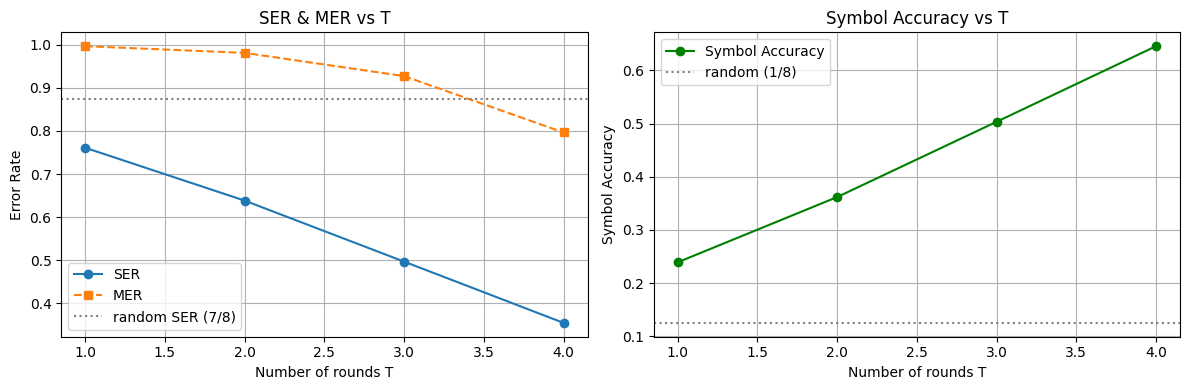


Round Ablation Summary:
   T       SER       MER    SymAcc
   1    0.7610    0.9968    0.2390
   2    0.6382    0.9812    0.3618
   3    0.4966    0.9273    0.5034
   4    0.3543    0.7964    0.6457 <- baseline


In [13]:
import json, os
import matplotlib.pyplot as plt
from IPython.display import display

round_results = {}
for t in [1, 2, 3]:
    path = f'results/bonus/ablations/rounds_T{t}/metrics/eval_results.json'
    if os.path.exists(path):
        with open(path) as f:
            round_results[t] = json.load(f)
    else:
        print(f'Missing T={t}: {path}')

baseline_path = 'results/bonus/metrics/eval_results.json'
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        round_results[4] = json.load(f)

if not round_results:
    print('No results found. Run the training cells above first.')
else:
    ts    = sorted(round_results)
    sers  = [round_results[t]['SER']  for t in ts]
    mers  = [round_results[t]['MER']  for t in ts]
    saccs = [round_results[t]['symbol_accuracy'] for t in ts]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(ts, sers, 'o-', label='SER')
    axes[0].plot(ts, mers, 's--', label='MER')
    axes[0].axhline(1 - 1/8, color='gray', linestyle=':', label='random SER (7/8)')
    axes[0].set_xlabel('Number of rounds T')
    axes[0].set_ylabel('Error Rate')
    axes[0].set_title('SER & MER vs T')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(ts, saccs, 'o-', color='green', label='Symbol Accuracy')
    axes[1].axhline(1/8, color='gray', linestyle=':', label='random (1/8)')
    axes[1].set_xlabel('Number of rounds T')
    axes[1].set_ylabel('Symbol Accuracy')
    axes[1].set_title('Symbol Accuracy vs T')
    axes[1].legend(); axes[1].grid(True)

    os.makedirs('results/bonus/ablations', exist_ok=True)
    plt.tight_layout()
    plt.savefig('results/bonus/ablations/round_ablation.png', dpi=100)
    display(fig)
    plt.close()

    print('\nRound Ablation Summary:')
    print(f'{"T":>4}  {"SER":>8}  {"MER":>8}  {"SymAcc":>8}')
    for t in ts:
        r = round_results[t]
        tag = ' <- baseline' if t == 4 else ''
        print(f'{t:>4}  {r["SER"]:>8.4f}  {r["MER"]:>8.4f}  {r["symbol_accuracy"]:>8.4f}{tag}')


---
## 9. Ablation 2 — Feedback Ablation

Compares two variants with T = 4:
- **With feedback** (baseline): TX receives `f_t = y_t` each round
- **No feedback**: TX receives `f_t = 0` — cannot adapt to channel observations

**Research question:** Does the system actually exploit the feedback channel?


In [14]:
!python bonus/experiment_bonus.py --no-feedback --out-dir results/bonus/ablations/no_feedback


Config: T=4 | sigma_sq=0.25 | feedback=False | out_dir=results/bonus/ablations/no_feedback
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.1971  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1279  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1035 | val=2.0677 | sym_acc=0.1475 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.0729 | val=2.0898 | sym_acc=0.1318 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.1036 | val=2.0651 | sym_acc=0.1357 | msg_acc=0.0000 | power=1.000000
Epoch    4 | train=2.0650 | val=2.0101 | sym_acc=0.2373 | msg_acc=0.0039 | power=1.000000
Epoch    5 | train=2.0307 | val=2.0016 | sym_acc=0.2070 | msg_acc=0.0000 | power=1.000000
Epoch    6 | train=2.0197 | val=1.9988 | sym_acc=0.2354 | msg_acc=0.0039 | power=1.000000
Epoch    7 | train=2.0104 | val=1.9623 | sym_acc=0.267

In [15]:
import json, os

paths = {
    'With Feedback (baseline)': 'results/bonus/metrics/eval_results.json',
    'No Feedback':              'results/bonus/ablations/no_feedback/metrics/eval_results.json',
}

fb_results = {}
for label, path in paths.items():
    if os.path.exists(path):
        with open(path) as f:
            fb_results[label] = json.load(f)
    else:
        print(f'Missing: {path}')

if len(fb_results) < 2:
    print('Some results are missing — check the paths above.')
else:
    rows = ['symbol_accuracy', 'message_accuracy', 'SER', 'MER']
    w, fb, nfb = 'With Feedback (baseline)', 'No Feedback', 'No Feedback'
    print(f'{"Metric":<22}  {"With Feedback":>15}  {"No Feedback":>12}  {"Delta":>8}')
    print('-' * 62)
    for m in rows:
        v_fb  = fb_results['With Feedback (baseline)'][m]
        v_nfb = fb_results['No Feedback'][m]
        delta = v_fb - v_nfb
        print(f'{m:<22}  {v_fb:>15.4f}  {v_nfb:>12.4f}  {delta:>+8.4f}')


Metric                    With Feedback   No Feedback     Delta
--------------------------------------------------------------
symbol_accuracy                  0.6457        0.3751   +0.2706
message_accuracy                 0.2036        0.0179   +0.1857
SER                              0.3543        0.6249   -0.2706
MER                              0.7964        0.9821   -0.1857


---
## 10. Ablation 3 — Noise Level Sweep

Trains and evaluates the system across noise levels sigma^2 in {0.05, 0.10, 0.25, 0.50, 1.00}.
- **sigma^2 = 0.25** is the baseline (already trained).
- Results saved to `results/bonus/ablations/noise_{tag}/`.

**Research question:** How does SER scale with noise? Does the system degrade gracefully?


In [16]:
noise_runs = [
    ('0.05', '0_05'),
    ('0.10', '0_10'),
    ('0.50', '0_50'),
    ('1.00', '1_00'),
]

for sigma, tag in noise_runs:
    print(f'\n=== sigma_sq = {sigma} ===')
    get_ipython().system(
        f'python bonus/experiment_bonus.py --sigma-sq {sigma} --out-dir results/bonus/ablations/noise_{tag}'
    )



=== sigma_sq = 0.05 ===
Config: T=4 | sigma_sq=0.05 | feedback=True | out_dir=results/bonus/ablations/noise_0_05
Running pre-training smoke tests...
[PASS] Forward pass shapes
[PASS] Power constraint: 1.000000 <= 1.0
[PASS] Init loss: 2.1932  (expected ≈ 2.0794)
[PASS] Init symbol accuracy: 0.1279  (expected ≈ 0.1250)
[PASS] Backward + optimizer step  (TX grads: 33, RX grads: 30)
All smoke tests passed.
Starting training...
Epoch    1 | train=2.1039 | val=2.0661 | sym_acc=0.1455 | msg_acc=0.0000 | power=1.000000
Epoch    2 | train=2.0703 | val=2.0822 | sym_acc=0.1406 | msg_acc=0.0000 | power=1.000000
Epoch    3 | train=2.1049 | val=2.0606 | sym_acc=0.1826 | msg_acc=0.0039 | power=1.000000
Epoch    4 | train=2.0629 | val=2.0603 | sym_acc=0.1191 | msg_acc=0.0000 | power=1.000000
Epoch    5 | train=2.0754 | val=1.9970 | sym_acc=0.2354 | msg_acc=0.0000 | power=1.000000
Epoch    6 | train=2.0117 | val=1.9958 | sym_acc=0.1787 | msg_acc=0.0000 | power=1.000000
Epoch    7 | train=2.0044 | val

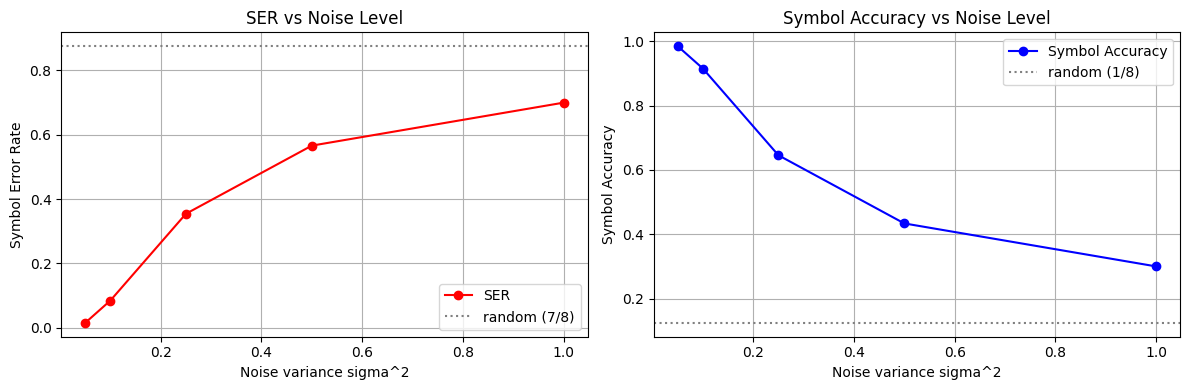


Noise Sweep Summary:
  sigma_sq       SER    SymAcc
      0.05    0.0155    0.9845
      0.10    0.0849    0.9151
      0.25    0.3543    0.6457 <- baseline
      0.50    0.5660    0.4340
      1.00    0.6995    0.3005


In [17]:
import json, os
import matplotlib.pyplot as plt
from IPython.display import display

sigma_map = {
    0.05: 'results/bonus/ablations/noise_0_05/metrics/eval_results.json',
    0.10: 'results/bonus/ablations/noise_0_10/metrics/eval_results.json',
    0.25: 'results/bonus/metrics/eval_results.json',
    0.50: 'results/bonus/ablations/noise_0_50/metrics/eval_results.json',
    1.00: 'results/bonus/ablations/noise_1_00/metrics/eval_results.json',
}

noise_results = {}
for s, p in sigma_map.items():
    if os.path.exists(p):
        with open(p) as f:
            noise_results[s] = json.load(f)
    else:
        print(f'Missing sigma={s}: {p}')

if not noise_results:
    print('No results found. Run the training cell above first.')
else:
    xs    = sorted(noise_results)
    sers  = [noise_results[s]['SER']  for s in xs]
    saccs = [noise_results[s]['symbol_accuracy'] for s in xs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(xs, sers, 'o-', color='red', label='SER')
    axes[0].axhline(1 - 1/8, color='gray', linestyle=':', label='random (7/8)')
    axes[0].set_xlabel('Noise variance sigma^2')
    axes[0].set_ylabel('Symbol Error Rate')
    axes[0].set_title('SER vs Noise Level')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(xs, saccs, 'o-', color='blue', label='Symbol Accuracy')
    axes[1].axhline(1/8, color='gray', linestyle=':', label='random (1/8)')
    axes[1].set_xlabel('Noise variance sigma^2')
    axes[1].set_ylabel('Symbol Accuracy')
    axes[1].set_title('Symbol Accuracy vs Noise Level')
    axes[1].legend(); axes[1].grid(True)

    os.makedirs('results/bonus/ablations', exist_ok=True)
    plt.tight_layout()
    plt.savefig('results/bonus/ablations/noise_sweep.png', dpi=100)
    display(fig)
    plt.close()

    print('\nNoise Sweep Summary:')
    print(f'{"sigma_sq":>10}  {"SER":>8}  {"SymAcc":>8}')
    for s in xs:
        r = noise_results[s]
        tag = ' <- baseline' if s == 0.25 else ''
        print(f'{s:>10.2f}  {r["SER"]:>8.4f}  {r["symbol_accuracy"]:>8.4f}{tag}')


---
## 11. Download All Results (Baseline + Ablations)


In [ ]:
import base64, shutil, os
from IPython.display import display, HTML

tmp_dir = "/tmp/bonus_all_results"
os.makedirs(tmp_dir, exist_ok=True)

for sub in ("metrics", "plots"):
    src = f"results/bonus/{sub}"
    if os.path.exists(src):
        shutil.copytree(src, f"{tmp_dir}/baseline/{sub}", dirs_exist_ok=True)

abl_root = "results/bonus/ablations"
if os.path.exists(abl_root):
    shutil.copytree(abl_root, f"{tmp_dir}/ablations", dirs_exist_ok=True)

zip_path = "/tmp/bonus_all_results"
shutil.make_archive(zip_path, "zip", tmp_dir)

with open(zip_path + ".zip", "rb") as f:
    b64 = base64.b64encode(f.read()).decode()

size_kb = len(b64) * 3 // 4 // 1024
display(HTML(f"""
<a href="data:application/zip;base64,{b64}"
   download="bonus_all_results.zip"
   style="padding:8px 16px;background:#1a73e8;color:white;
          text-decoration:none;border-radius:4px;font-family:sans-serif;">
    &#11015; Download bonus_all_results.zip ({size_kb} KB)
</a>
"""))
